In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import natural_earth, Reader
from matplotlib.patches import Patch

# Rutas
ROOT      = Path("..") 
DIR_NOAA  = ROOT / "datos/crudos/indices_noaa"
DIR_ERA5  = ROOT / "datos/crudos/era5"

print("Rutas configuradas:")
print(f"  NOAA : {DIR_NOAA.resolve()}")
print(f"  ERA5 : {DIR_ERA5.resolve()}")

Rutas configuradas:
  NOAA : /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 4/datos/crudos/indices_noaa
  ERA5 : /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 4/datos/crudos/era5


In [2]:
def leer_noaa(filepath, nombre):
    """Lee archivos de índices NOAA en formato año + 12 meses."""
    df = pd.read_csv(
        filepath,
        skiprows=1,
        skipfooter=3,
        sep=r'\s+',
        header=None,
        names=['year','Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec'],
        engine='python'
    )
    # Eliminar filas donde el año no es válido
    df = df[df['year'] > 0].copy()

    # Convertir a serie temporal mensual
    df = df.melt(id_vars='year', var_name='month', value_name=nombre)
    df['month'] = pd.to_datetime(df['month'], format='%b').dt.month
    df['time']  = pd.to_datetime(df[['year','month']].assign(day=1))
    df = df[['time', nombre]].sort_values('time').reset_index(drop=True)

    # Reemplazar missing
    df[nombre] = df[nombre].replace(-99.99, np.nan)

    return df

nino34 = leer_noaa(DIR_NOAA / "nino34.data",        "nino34")
amo    = leer_noaa(DIR_NOAA / "amo_unsmoothed.data", "amo")

print("Niño 3.4:")
print(f"  {nino34.time.iloc[0].date()} → {nino34.time.iloc[-1].date()}")
print(f"  NaN: {nino34.nino34.isna().sum()}")
print(f"  Rango: {nino34.nino34.min():.2f} – {nino34.nino34.max():.2f}")

print("\nAMO:")
print(f"  {amo.time.iloc[0].date()} → {amo.time.iloc[-1].date()}")
print(f"  NaN: {amo.amo.isna().sum()}")
print(f"  Rango: {amo.amo.min():.2f} – {amo.amo.max():.2f}")

Niño 3.4:
  1948-01-01 → 2026-12-01
  NaN: 32
  Rango: 24.25 – 29.42

AMO:
  1948-01-01 → 2023-12-01
  NaN: 11
  Rango: -0.54 – 0.66


In [3]:
# Cargar ERA5
precip = xr.open_dataset(DIR_ERA5 / "era5_precip_ejc.nc")
t2m    = xr.open_dataset(DIR_ERA5 / "era5_t2m_ejc.nc")

# Renombrar dimensión temporal
precip = precip.rename({'valid_time': 'time'})
t2m    = t2m.rename({'valid_time': 'time'})

# Conversión de unidades
# tp: m/día → mm/mes (ERA5 mensual ya es acumulado mensual en metros)
precip['tp'] = precip['tp'] * 1000  # m → mm

# t2m: K → °C
t2m['t2m'] = t2m['t2m'] - 273.15

# Verificar
print("PRECIPITACIÓN (mm/mes):")
print(f"  Tiempo: {str(precip.time.values[0])[:10]} → {str(precip.time.values[-1])[:10]}")
print(f"  Rango: {float(precip.tp.min()):.1f} – {float(precip.tp.max()):.1f} mm")

print("\nTEMPERATURA 2m (°C):")
print(f"  Tiempo: {str(t2m.time.values[0])[:10]} → {str(t2m.time.values[-1])[:10]}")
print(f"  Rango: {float(t2m.t2m.min()):.1f} – {float(t2m.t2m.max()):.1f} °C")

PRECIPITACIÓN (mm/mes):
  Tiempo: 1950-01-01 → 2023-12-01
  Rango: 0.0 – 170.2 mm

TEMPERATURA 2m (°C):
  Tiempo: 1950-01-01 → 2023-12-01
  Rango: 6.9 – 32.6 °C


In [4]:
# Período común a los cuatro datasets
t_ini = '1950-01-01'
t_fin = '2023-12-01'

# Recortar índices NOAA
nino34 = nino34[(nino34.time >= t_ini) & (nino34.time <= t_fin)].reset_index(drop=True)
amo    = amo   [(amo.time    >= t_ini) & (amo.time    <= t_fin)].reset_index(drop=True)

# Recortar ERA5
precip = precip.sel(time=slice(t_ini, t_fin))
t2m    = t2m.sel(  time=slice(t_ini, t_fin))

# Anomalías ERA5: restar climatología mensual (1981–2010)
def anomalia(ds, var):
    clim = ds[var].sel(time=slice('1981-01-01','2010-12-01')).groupby('time.month').mean()
    return ds[var].groupby('time.month') - clim

precip_anom = anomalia(precip, 'tp')
t2m_anom    = anomalia(t2m,    't2m')

# Anomalía Niño 3.4: climatología mensual 1981–2010 correcta
clim_nino = (
    nino34[(nino34.time >= '1981-01-01') & (nino34.time <= '2010-12-01')]
    .groupby(
        nino34[(nino34.time >= '1981-01-01') & (nino34.time <= '2010-12-01')]
        .time.dt.month
    )['nino34'].mean()
)
nino34['mes'] = nino34['time'].dt.month
nino34['nino34_anom'] = nino34['nino34'] - nino34['mes'].map(clim_nino)
nino34 = nino34.drop(columns='mes')

print(f"Período común: {t_ini} → {t_fin}  ({len(nino34)} meses)")
print(f"Niño 3.4 — válidos: {nino34.nino34_anom.notna().sum()}  rango: {nino34.nino34_anom.min():.2f} – {nino34.nino34_anom.max():.2f} °C")
print(f"AMO      — rango: {amo.amo.min():.2f} – {amo.amo.max():.2f} °C")
print(f"Precip anomalía — rango: {float(precip_anom.min()):.1f} – {float(precip_anom.max()):.1f} mm")
print(f"T2m anomalía    — rango: {float(t2m_anom.min()):.1f} – {float(t2m_anom.max()):.1f} °C")

Período común: 1950-01-01 → 2023-12-01  (888 meses)
Niño 3.4 — válidos: 888  rango: -2.38 – 2.79 °C
AMO      — rango: -0.54 – 0.66 °C
Precip anomalía — rango: -63.3 – 75.1 mm
T2m anomalía    — rango: -5.0 – 4.8 °C


In [5]:
from scipy import stats

def corr_rezagada(indice_df, col_indice, era5_anom, lags_meses):
    """
    Calcula correlación de Pearson entre un índice y una variable ERA5
    para cada rezago y cada punto de grilla.
    Retorna DataArray (lag, lat, lon) con correlaciones y p-valores.
    """
    # Serie del índice como array
    idx = indice_df[col_indice].values  # (888,)

    lats = era5_anom.latitude.values
    lons = era5_anom.longitude.values
    n_lags = len(lags_meses)

    r_map = np.full((n_lags, len(lats), len(lons)), np.nan)
    p_map = np.full((n_lags, len(lats), len(lons)), np.nan)

    for il, lag in enumerate(lags_meses):
        if lag >= 0:
            # índice en t, variable en t+lag
            idx_slice = idx[:888 - lag]
            era_slice = era5_anom.isel(time=slice(lag, 888))
        else:
            # índice en t, variable en t+lag (lag negativo → variable adelantada)
            idx_slice = idx[-lag:]
            era_slice = era5_anom.isel(time=slice(0, 888 + lag))

        for ilat, _ in enumerate(lats):
            for ilon, _ in enumerate(lons):
                var_pts = era_slice.isel(latitude=ilat, longitude=ilon).values
                # Máscara NaN
                mask = ~(np.isnan(idx_slice) | np.isnan(var_pts))
                if mask.sum() > 30:
                    r, p = stats.pearsonr(idx_slice[mask], var_pts[mask])
                    r_map[il, ilat, ilon] = r
                    p_map[il, ilat, ilon] = p

    # Empaquetar en DataArrays
    coords = {'lag': lags_meses, 'latitude': lats, 'longitude': lons}
    da_r = xr.DataArray(r_map, coords=coords, dims=['lag','latitude','longitude'])
    da_p = xr.DataArray(p_map, coords=coords, dims=['lag','latitude','longitude'])
    return da_r, da_p

# Rezagos a evaluar: índice lidera la variable de 0 a 12 meses
lags = list(range(0, 13))

print("Calculando correlaciones (4 pares × 13 rezagos)...")

r_nino_tp, p_nino_tp = corr_rezagada(nino34, 'nino34_anom', precip_anom, lags)
print("  ✓ Niño 3.4 vs Precipitación")

r_nino_t2, p_nino_t2 = corr_rezagada(nino34, 'nino34_anom', t2m_anom,   lags)
print("  ✓ Niño 3.4 vs Temperatura")

r_amo_tp,  p_amo_tp  = corr_rezagada(amo,    'amo',         precip_anom, lags)
print("  ✓ AMO vs Precipitación")

r_amo_t2,  p_amo_t2  = corr_rezagada(amo,    'amo',         t2m_anom,   lags)
print("  ✓ AMO vs Temperatura")

print("\nListo. Shape de cada mapa:", r_nino_tp.shape)

Calculando correlaciones (4 pares × 13 rezagos)...
  ✓ Niño 3.4 vs Precipitación
  ✓ Niño 3.4 vs Temperatura
  ✓ AMO vs Precipitación
  ✓ AMO vs Temperatura

Listo. Shape de cada mapa: (13, 17, 17)


In [6]:
# Rezago óptimo: lag donde |r| es máximo en cada punto
def lag_optimo(da_r):
    """Retorna mapa 2D con el rezago de máxima correlación absoluta."""
    idx_max = np.abs(da_r).argmax(dim='lag')
    r_max   = da_r.isel(lag=idx_max)
    lag_max = da_r.lag.isel(lag=idx_max)
    return r_max, lag_max

r_max_nino_tp, lag_nino_tp = lag_optimo(r_nino_tp)
r_max_nino_t2, lag_nino_t2 = lag_optimo(r_nino_t2)
r_max_amo_tp,  lag_amo_tp  = lag_optimo(r_amo_tp)
r_max_amo_t2,  lag_amo_t2  = lag_optimo(r_amo_t2)

print("Correlación máxima promedio sobre la región:")
print(f"  Niño 3.4 vs Precip : r = {float(r_max_nino_tp.mean()):.3f}  lag modal = {int(lag_nino_tp.values.flatten().tolist().count(lag_nino_tp.values.flatten().tolist()[0]))} meses")
print(f"  Niño 3.4 vs T2m    : r = {float(r_max_nino_t2.mean()):.3f}")
print(f"  AMO      vs Precip : r = {float(r_max_amo_tp.mean()):.3f}")
print(f"  AMO      vs T2m    : r = {float(r_max_amo_t2.mean()):.3f}")

# Lag más frecuente por par
for nombre, lag_map in [
    ("Niño 3.4 vs Precip", lag_nino_tp),
    ("Niño 3.4 vs T2m",    lag_nino_t2),
    ("AMO      vs Precip", lag_amo_tp),
    ("AMO      vs T2m",    lag_amo_t2),
]:
    vals = lag_map.values.flatten().astype(int).tolist()
    lag_modal = max(set(vals), key=vals.count)
    print(f"  Lag modal {nombre}: {lag_modal} mes(es)")

Correlación máxima promedio sobre la región:
  Niño 3.4 vs Precip : r = -0.207  lag modal = 111 meses
  Niño 3.4 vs T2m    : r = 0.508
  AMO      vs Precip : r = -0.043
  AMO      vs T2m    : r = 0.251
  Lag modal Niño 3.4 vs Precip: 0 mes(es)
  Lag modal Niño 3.4 vs T2m: 2 mes(es)
  Lag modal AMO      vs Precip: 0 mes(es)
  Lag modal AMO      vs T2m: 0 mes(es)


In [7]:
print(nino34[nino34['nino34_anom'].notna()].head(5))
print(nino34[nino34['nino34_anom'].notna()].tail(5))
print(f"\nTotal válidos: {nino34['nino34_anom'].notna().sum()} de {len(nino34)}")
print(f"Primer válido: {nino34.loc[nino34['nino34_anom'].notna(), 'time'].iloc[0].date()}")

        time  nino34  nino34_anom
0 1950-01-01   24.55    -2.002333
1 1950-02-01   25.06    -1.681667
2 1950-03-01   25.87    -1.364667
3 1950-04-01   26.28    -1.429667
4 1950-05-01   26.18    -1.632000
          time  nino34  nino34_anom
883 2023-08-01   28.20     1.366000
884 2023-09-01   28.32     1.592667
885 2023-10-01   28.44     1.767000
886 2023-11-01   28.72     2.092333
887 2023-12-01   28.62     2.059000

Total válidos: 888 de 888
Primer válido: 1950-01-01


Punto seleccionado:
  lat = 4.50°N
  lon = -75.75°W
Precip — rango: -13.6 – 21.9 mm
T2m    — rango: -2.43 – 2.22 °C


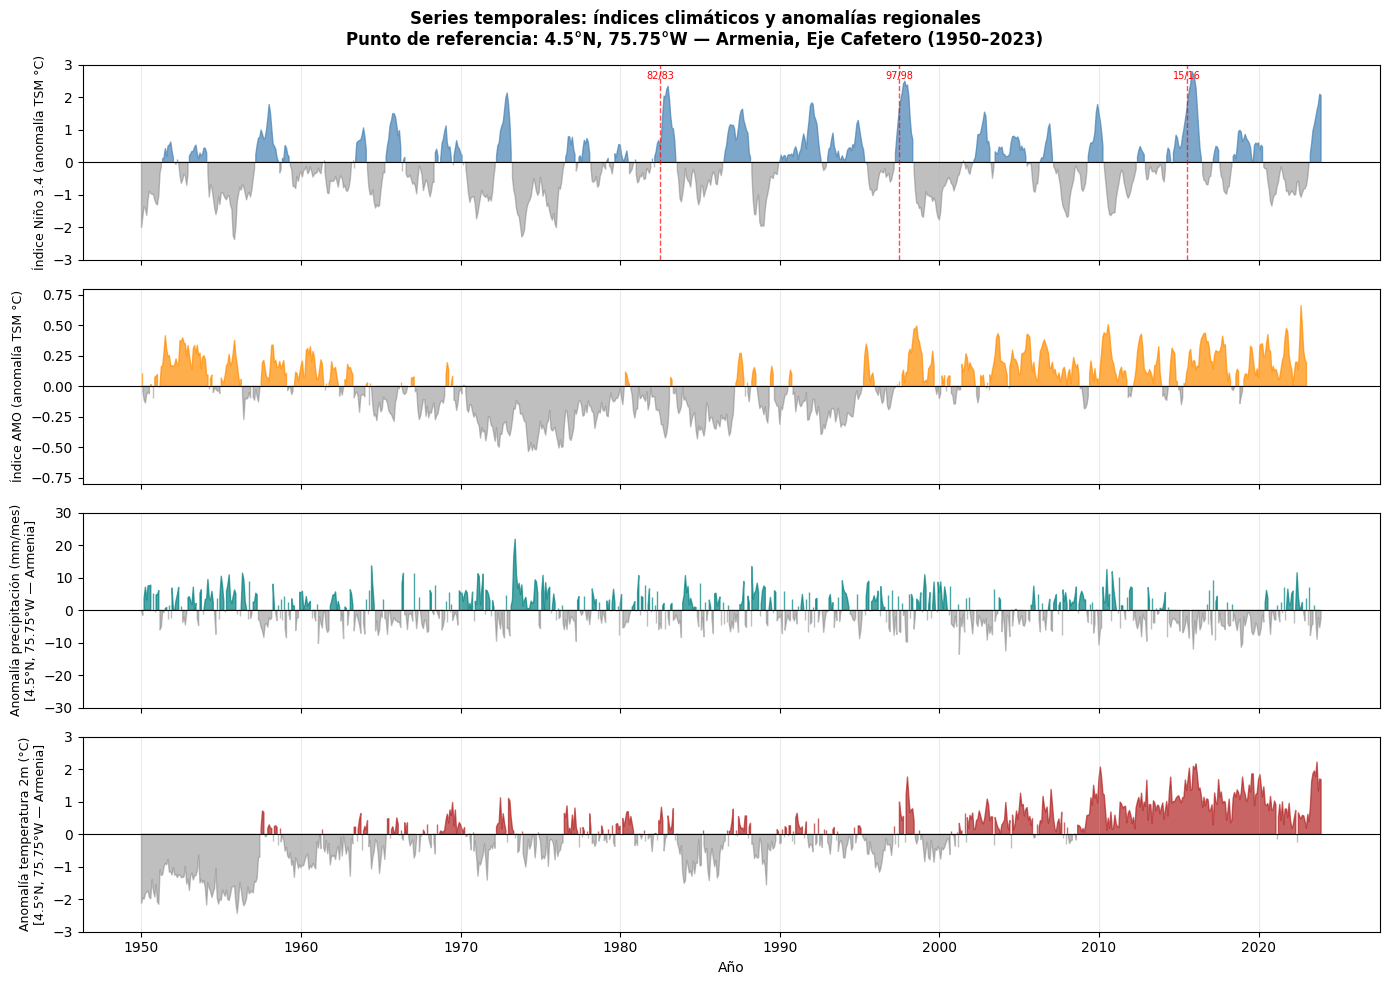

Figura guardada.


In [15]:
# Punto representativo: Armenia (núcleo Eje Cafetero)
lat_ref, lon_ref = 4.5, -75.7

precip_ts = precip_anom.sel(latitude=lat_ref, longitude=lon_ref, method='nearest')
t2m_ts    = t2m_anom.sel(  latitude=lat_ref, longitude=lon_ref, method='nearest')

print(f"Punto seleccionado:")
print(f"  lat = {float(precip_ts.latitude):.2f}°N")
print(f"  lon = {float(precip_ts.longitude):.2f}°W")
print(f"Precip — rango: {float(precip_ts.min()):.1f} – {float(precip_ts.max()):.1f} mm")
print(f"T2m    — rango: {float(t2m_ts.min()):.2f} – {float(t2m_ts.max()):.2f} °C")

tiempo = pd.to_datetime(precip_anom.time.values)

df_ts = pd.DataFrame({
    'time':        tiempo,
    'nino34':      nino34['nino34_anom'].values,
    'amo':         amo['amo'].values,
    'precip_anom': precip_ts.values,
    't2m_anom':    t2m_ts.values,
})

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

pares_ts = [
    ('nino34',      'Índice Niño 3.4 (anomalía TSM °C)',          'steelblue',  (-3,   3)),
    ('amo',         'Índice AMO (anomalía TSM °C)',                'darkorange', (-0.8, 0.8)),
    ('precip_anom', 'Anomalía precipitación (mm/mes)\n[4.5°N, 75.75°W — Armenia]', 'teal',     (-30, 30)),
    ('t2m_anom',    'Anomalía temperatura 2m (°C)\n[4.5°N, 75.75°W — Armenia]',    'firebrick', (-3,   3)),
]

for ax, (col, ylabel, color, ylim) in zip(axes, pares_ts):
    vals = df_ts[col].values.astype(float)
    ax.fill_between(df_ts['time'], vals, 0,
                    where=(vals >= 0), color=color, alpha=0.7)
    ax.fill_between(df_ts['time'], vals, 0,
                    where=(vals < 0),  color='gray', alpha=0.5)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(ylim)
    ax.grid(axis='x', linewidth=0.4, alpha=0.5)

    if col == 'nino34':
        for yr, label in [(1982,'82/83'),(1997,'97/98'),(2015,'15/16')]:
            ax.axvline(pd.Timestamp(f'{yr}-07-01'), color='red',
                       linewidth=1, linestyle='--', alpha=0.7)
            ax.text(pd.Timestamp(f'{yr}-07-01'), ylim[1]*0.85,
                    label, color='red', fontsize=7, ha='center')

axes[-1].set_xlabel('Año', fontsize=10)
fig.suptitle(
    "Series temporales: índices climáticos y anomalías regionales\n"
    "Punto de referencia: 4.5°N, 75.75°W — Armenia, Eje Cafetero (1950–2023)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig("../figuras/fig2_series_temporales.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

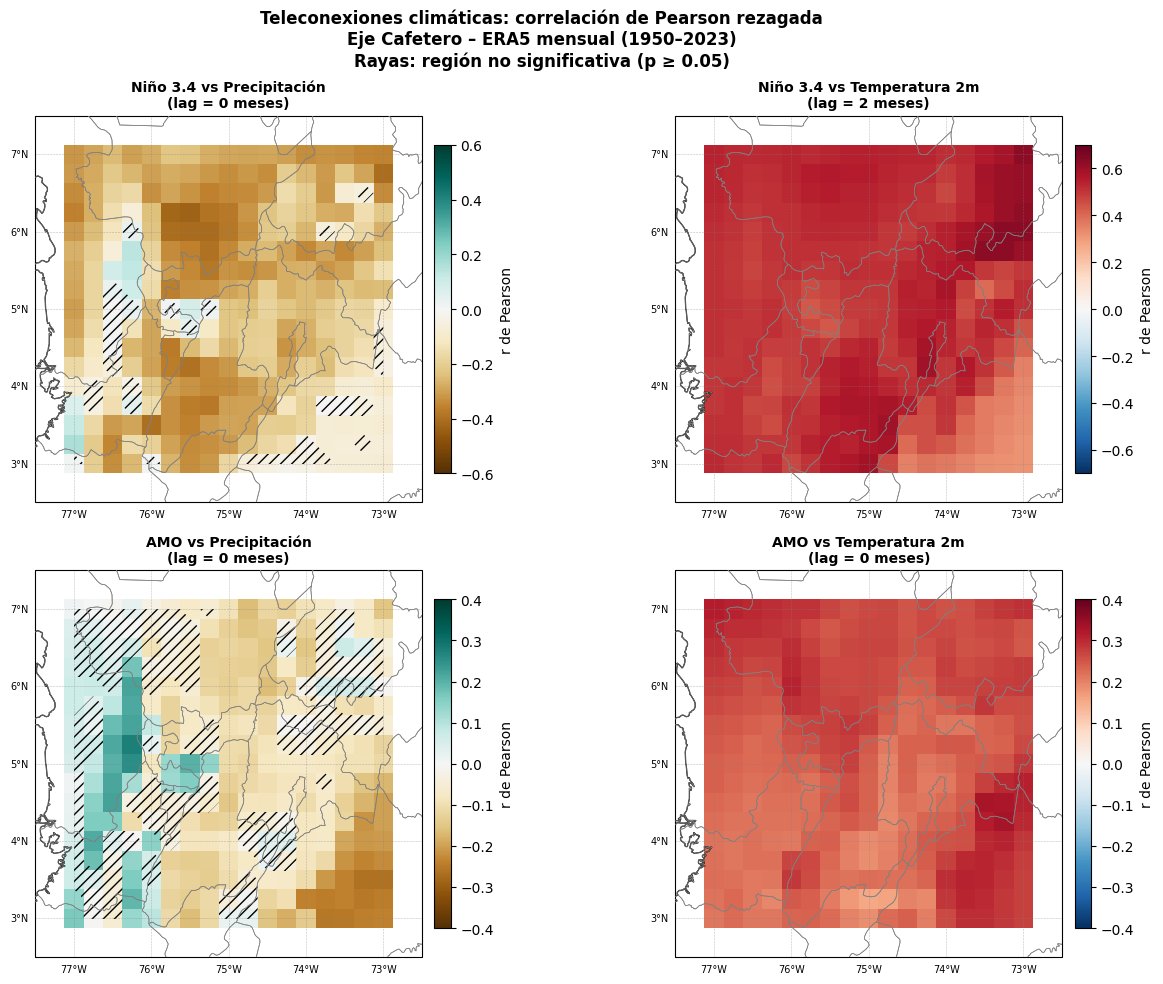

Figura guardada.


In [9]:
fig, axes = plt.subplots(
    2, 2, figsize=(13, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Lag fijo por par (basado en resultados celda 6)
pares = [
    (r_nino_tp.sel(lag=0),  "Niño 3.4 vs Precipitación",  "BrBG",   (-0.6, 0.6), "lag = 0 meses"),
    (r_nino_t2.sel(lag=2),  "Niño 3.4 vs Temperatura 2m", "RdBu_r", (-0.7, 0.7), "lag = 2 meses"),
    (r_amo_tp.sel(lag=0),   "AMO vs Precipitación",        "BrBG",   (-0.4, 0.4), "lag = 0 meses"),
    (r_amo_t2.sel(lag=0),   "AMO vs Temperatura 2m",       "RdBu_r", (-0.4, 0.4), "lag = 0 meses"),
]

# Significance mask (p < 0.05)
p_pares = [
    p_nino_tp.sel(lag=0),
    p_nino_t2.sel(lag=2),
    p_amo_tp.sel(lag=0),
    p_amo_t2.sel(lag=0),
]

for ax, (r_map, titulo, cmap, vlim, lag_str), p_map in zip(axes.flat, pares, p_pares):

    # Mapa de correlación
    im = ax.pcolormesh(
        r_map.longitude, r_map.latitude, r_map.values,
        cmap=cmap, vmin=vlim[0], vmax=vlim[1],
        transform=ccrs.PlateCarree(), zorder=1
    )

    # Hatching donde p >= 0.05 (no significativo)
    ax.contourf(
        r_map.longitude, r_map.latitude,
        (p_map.values >= 0.05).astype(float),
        levels=[0.5, 1.5], hatches=['///'], colors='none',
        transform=ccrs.PlateCarree(), zorder=2
    )

    # Features geográficas
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.9, zorder=3)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.9, zorder=3)
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.5,
                   edgecolor='gray', zorder=3)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='none', zorder=0)

    ax.set_extent([-77.5, -72.5, 2.5, 7.5], crs=ccrs.PlateCarree())

    # Grilla
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                      alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

    ax.set_title(f"{titulo}\n({lag_str})", fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02,
                 label='r de Pearson', shrink=0.85)

fig.suptitle(
    "Teleconexiones climáticas: correlación de Pearson rezagada\n"
    "Eje Cafetero – ERA5 mensual (1950–2023)\n"
    "Rayas: región no significativa (p ≥ 0.05)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig("../figuras/fig1_mapas_correlacion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

In [10]:
print("r_nino_tp en lag=0, punto central:")
print(float(r_nino_tp.sel(lag=0).isel(latitude=8, longitude=8)))

print("\nCorrelación directa Niño3.4 vs precip en punto central:")
from scipy.stats import pearsonr
pt = precip_anom.isel(latitude=8, longitude=8).values
r, p = pearsonr(nino34['nino34_anom'].values, pt)
print(f"  r = {r:.3f}, p = {p:.4f}")

r_nino_tp en lag=0, punto central:
-0.2276593385914356

Correlación directa Niño3.4 vs precip en punto central:
  r = -0.228, p = 0.0000


Punto: 4.50°N, -75.75°W
Precip — rango: -13.6 – 21.9 mm
T2m    — rango: -2.43 – 2.22 °C
Verificación lag=0: r=-0.374


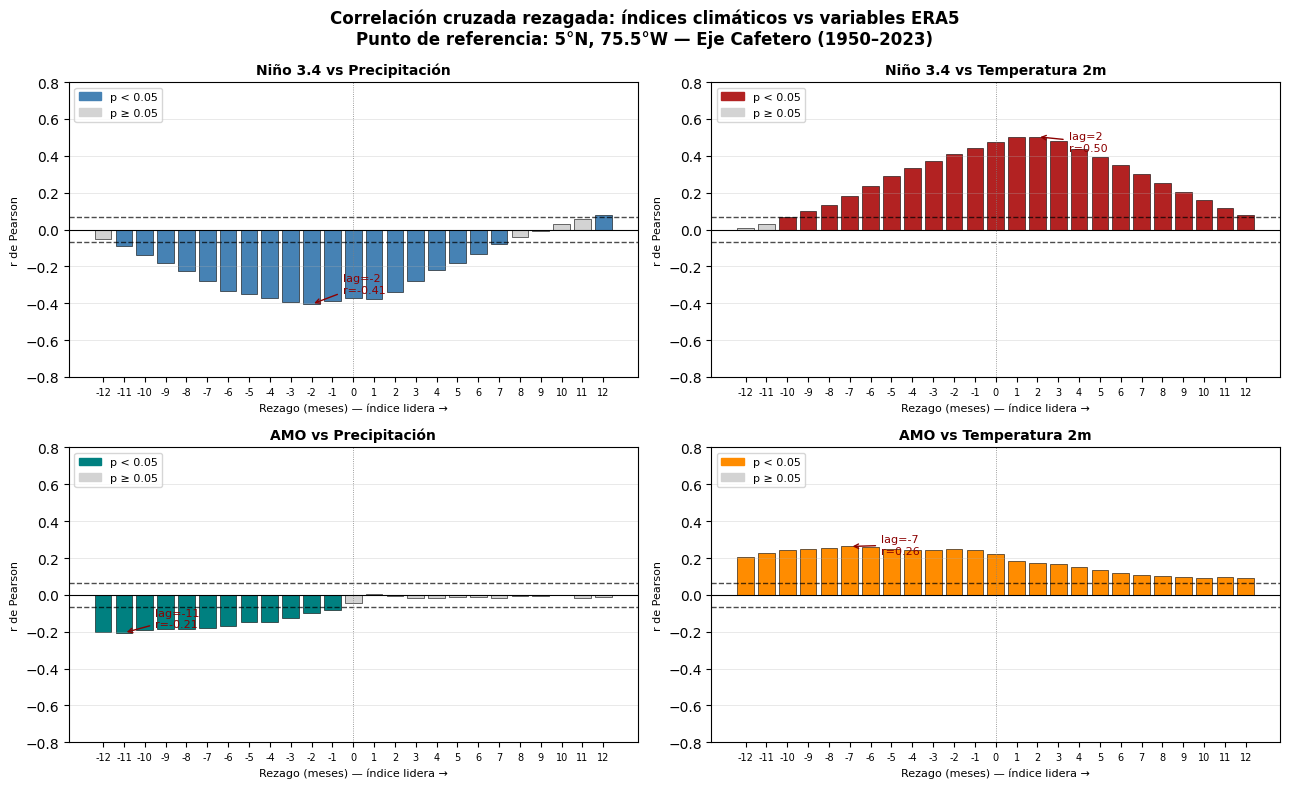

Figura guardada.


In [14]:
from scipy.stats import pearsonr

# Punto de referencia corregido: Armenia
lat_ref, lon_ref = 4.5, -75.7

precip_pt = precip_anom.sel(latitude=lat_ref, longitude=lon_ref, method='nearest').values
t2m_pt    = t2m_anom.sel(  latitude=lat_ref, longitude=lon_ref, method='nearest').values

pt_check = precip_anom.sel(latitude=lat_ref, longitude=lon_ref, method='nearest')
print(f"Punto: {float(pt_check.latitude):.2f}°N, {float(pt_check.longitude):.2f}°W")
print(f"Precip — rango: {precip_pt.min():.1f} – {precip_pt.max():.1f} mm")
print(f"T2m    — rango: {t2m_pt.min():.2f} – {t2m_pt.max():.2f} °C")
print(f"Verificación lag=0: r={pearsonr(nino34.nino34_anom.values, precip_pt)[0]:.3f}")

# Correlación cruzada para lags -12 a +12
lags_full = list(range(-12, 13))
n = 888

def xcorr_series(idx, var, lags):
    rs, ps = [], []
    for lag in lags:
        if lag >= 0:
            i, v = idx[:n-lag], var[lag:]
        else:
            i, v = idx[-lag:], var[:n+lag]
        mask = ~(np.isnan(i) | np.isnan(v))
        if mask.sum() > 30:
            r, p = pearsonr(i[mask], v[mask])
        else:
            r, p = np.nan, np.nan
        rs.append(r)
        ps.append(p)
    return np.array(rs), np.array(ps)

# Nivel de significancia (umbral r para p<0.05, n~888)
# r_crit ≈ 1.96/sqrt(n)
r_crit = 1.96 / np.sqrt(n)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)

combos = [
    (nino34['nino34_anom'].values, precip_pt, "Niño 3.4 vs Precipitación", "steelblue"),
    (nino34['nino34_anom'].values, t2m_pt,    "Niño 3.4 vs Temperatura 2m","firebrick"),
    (amo['amo'].values,            precip_pt, "AMO vs Precipitación",       "teal"),
    (amo['amo'].values,            t2m_pt,    "AMO vs Temperatura 2m",      "darkorange"),
]

for ax, (idx, var, titulo, color) in zip(axes.flat, combos):
    rs, ps = xcorr_series(idx, var, lags_full)

    # Barras
    colors_bar = [color if p < 0.05 else 'lightgray' for p in ps]
    ax.bar(lags_full, rs, color=colors_bar, edgecolor='k', linewidth=0.4)

    # Líneas de significancia
    ax.axhline( r_crit, color='k', linewidth=1, linestyle='--', alpha=0.7)
    ax.axhline(-r_crit, color='k', linewidth=1, linestyle='--', alpha=0.7)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')

    # Marcar lag de máxima correlación absoluta
    idx_max = np.nanargmax(np.abs(rs))
    ax.annotate(f"lag={lags_full[idx_max]}\nr={rs[idx_max]:.2f}",
                xy=(lags_full[idx_max], rs[idx_max]),
                xytext=(lags_full[idx_max]+1.5, rs[idx_max]*0.85),
                fontsize=8, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1))

    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel("Rezago (meses) — índice lidera →", fontsize=8)
    ax.set_ylabel("r de Pearson", fontsize=8)
    ax.set_xticks(lags_full)
    ax.set_xticklabels(lags_full, fontsize=7)
    ax.set_ylim(-0.8, 0.8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)

    # Leyenda
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color=color,       label='p < 0.05'),
        Patch(color='lightgray', label='p ≥ 0.05'),
    ], fontsize=8, loc='upper left')

fig.suptitle(
    "Correlación cruzada rezagada: índices climáticos vs variables ERA5\n"
    "Punto de referencia: 5°N, 75.5°W — Eje Cafetero (1950–2023)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig("../figuras/fig3_correlograma.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

In [12]:
# Verificar qué punto exacto se está usando
pt_precip = precip_anom.sel(latitude=5.0, longitude=-75.5, method='nearest')
print(f"Lat exacta: {float(pt_precip.latitude):.2f}")
print(f"Lon exacta: {float(pt_precip.longitude):.2f}")

# Verificar correlación en lag=0 y lag=6
for lag in [0, 3, 6]:
    idx = nino34['nino34_anom'].values
    var = pt_precip.values
    if lag >= 0:
        r, p = pearsonr(idx[:888-lag], var[lag:])
    print(f"lag={lag}: r={r:.3f}, p={p:.4f}")

Lat exacta: 5.00
Lon exacta: -75.50
lag=0: r=0.087, p=0.0097
lag=3: r=0.201, p=0.0000
lag=6: r=0.227, p=0.0000


In [13]:
# Revisar correlación lag=0 en varios puntos del núcleo cafetero
puntos = {
    'Armenia (4.5N, 75.7W)':    (4.5, -75.7),
    'Manizales (5.1N, 75.5W)':  (5.1, -75.5),
    'Pereira (4.8N, 75.7W)':    (4.8, -75.7),
    'Ibagué (4.4N, 75.2W)':     (4.4, -75.2),
}

for nombre, (lat, lon) in puntos.items():
    pt = precip_anom.sel(latitude=lat, longitude=lon, method='nearest').values
    r0, p0 = pearsonr(nino34['nino34_anom'].values, pt)
    r3, p3 = pearsonr(nino34['nino34_anom'].values[:885], pt[3:])
    print(f"{nombre}: lag0 r={r0:.3f} (p={p0:.3f}) | lag3 r={r3:.3f} (p={p3:.3f})")

Armenia (4.5N, 75.7W): lag0 r=-0.374 (p=0.000) | lag3 r=-0.281 (p=0.000)
Manizales (5.1N, 75.5W): lag0 r=0.087 (p=0.010) | lag3 r=0.201 (p=0.000)
Pereira (4.8N, 75.7W): lag0 r=-0.114 (p=0.001) | lag3 r=0.018 (p=0.603)
Ibagué (4.4N, 75.2W): lag0 r=-0.166 (p=0.000) | lag3 r=-0.137 (p=0.000)
